## Google Trends Data

Google trends is a very useful source of time series data. Google collects information on the popularity of searches over time and we can use this to get an idea of regional or global interest in any topic. 

Note: You can also add comparisons if you are interested in multivariate time series analysis. 

### Interest in Climate Change 

Here we consider the searches for 'climate change'. By considering global Google searches, we can see if interest in climate change has increased over the last 5 years, and forecast if this interest will increase or not. 

You can see the source of this data here: https://trends.google.com/trends/explore?date=today%205-y&q=climate%20change

In particular here we will explore using AR and ARMA models for modelling this Google trends data, specifically searches of 'climate change' over the last 5 years worlwide. We will then explore methods for testing the model fits and the forecasts.

In [1]:
import re
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.api import tsa
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.ar_model import ar_select_order
from statsmodels.graphics.tsaplots import plot_acf

%matplotlib inline

## 1) Load and transform the data

Load the data into a `pandas.DataFrame` object. You can use the `pd.read_csv` function with the parameter `skiprows` to ignore the first row. 

Then:

1) Make the `Week` column of datetime format

2) Set the `Week` as the index column

3) Convert the dataframe to a pandas series by selecting the one remaining column `climate change: (Worldwide)`.

In [2]:
# Your code here...

#Skip the first row
df = pd.read_csv('data/climate_change.csv',skiprows=2)
# Assign the 'Week' column to a datetime format
df['Week'] = pd.to_datetime(df['Week'])
# Set the 'Week' column to be the index
df.set_index('Week', inplace=True)
# Select the values to form a time series
df = df['climate change: (Worldwide)']
df.head()



Week
2015-08-16    17
2015-08-23    16
2015-08-30    19
2015-09-06    20
2015-09-13    22
Name: climate change: (Worldwide), dtype: int64

In [3]:
# For our model building later, we attach a data frequency to the times. This is not essential but avoids warnings
df.index = pd.DatetimeIndex(
    df.index.values,
    freq=df.index.inferred_freq
)

time_series = df

## 2) Visualise the data with a plot

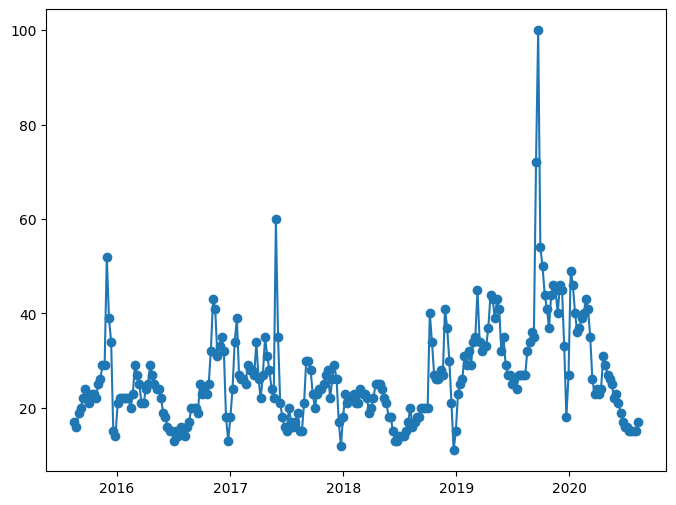

In [4]:
# Your code here...
plt.figure(figsize=(8, 6))
plt.plot(time_series, '-o', label="original data")
plt.show()


## 3) Fit the data

### Task:

1) Using `ar_select_order()` select the optimal AR parameter according to the AIC. 

2) Then fit the time series model using `tsa.AutoReg()` and the optimal lag found

3) Form a prediction starting at the optimal lag value. Hint: use the parameter `start`.

4) Plot the resulting prediction and original time series

Optimal p = 3


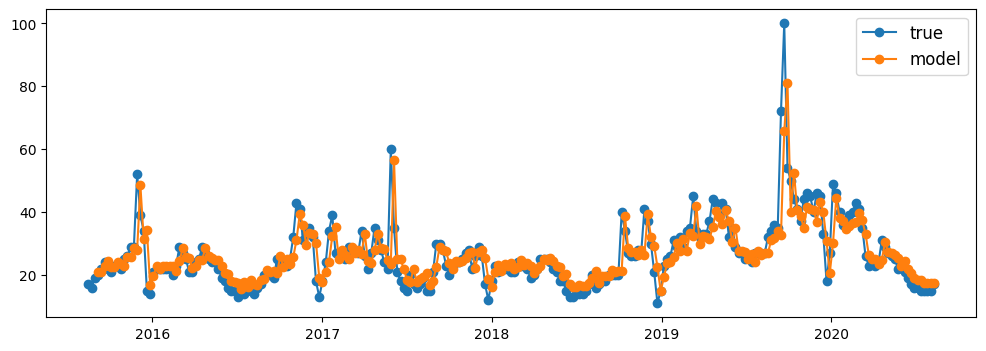

In [5]:
# Your code here...
mod = ar_select_order(time_series, maxlag=10, ic="aic")
optlag = max(mod.ar_lags)
print('Optimal p =', optlag)

ar = tsa.AutoReg(time_series, lags=optlag)
ar_result = ar.fit()
prediction = ar_result.predict(start=optlag)

plt.figure(figsize=(12, 4))
plt.plot(time_series, '-o', label='true')
plt.plot(prediction, '-o', label='model')
plt.legend(fontsize=12);


### Residual diagnostics

By using `time_series[optlag:].value.flatten()` as the original time series (this should align with your prediction), define the residuals from the AR model fit. 

Plot these residuals and the ACF in order to assess if this model is adequte. 

**Recall:** We want the residuals to have zero mean and be uncorrelated

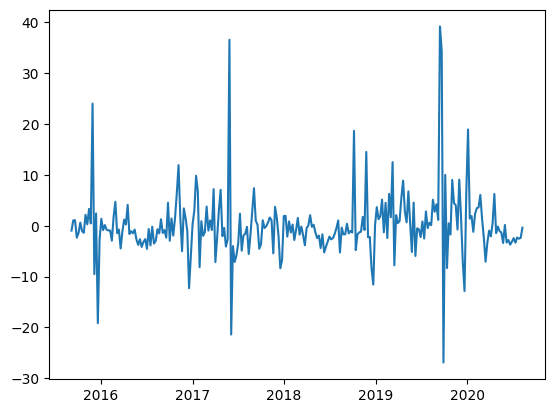

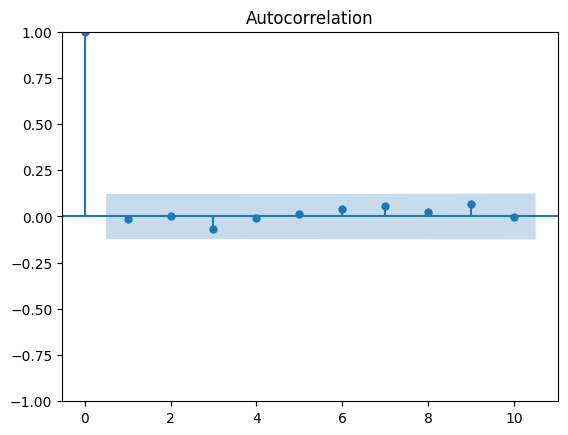

In [6]:
# Your code here...
# Form the residuals
fit_residuals = time_series[optlag:].values.flatten() - prediction

# Plot the residuals
plt.plot(fit_residuals)
plt.show()

# Plot the acf 
plot_acf(fit_residuals, lags=10)
plt.show()


## 4) Forecasting

**Note**: forecasting with time series data is **tricky** and usually basic methods do not really provide very good results (especially on realistic data). ARMA models are nice because they are simple but do not expect fantastic performances. (On the other hand, predicting the future is hard! -- who would have thought).

* Separate the time series into a training set and a test set formed of the last 40 points. 
  - To do this you can index `time_series` with `[:-40]` and `[-40:]`
* Fit an AR model on the training data and try to find the optimal lag using the `BIC` criterion, an alternative to the AIC which also accounts for the sample size. 
  - Use the `ar_select_order` function on your training data and use the parameters `maxlag` and `ic`
  - Then use the `AutoReg` function with your training data and use the `lags` parameter to specify the optimal lags found
* Predict and show the prediction on the original time series. Did it do a good job? 
  - For this step you will find the `.fit()` and `.predict()` functions useful
  - Note that for the prediction, we want to store the indices `[-len(test):]` as these are form our forecast
* compute the MAE
  - The function `mean_absolute_error` will let you do this

1
Out of sample MAE = 8.199


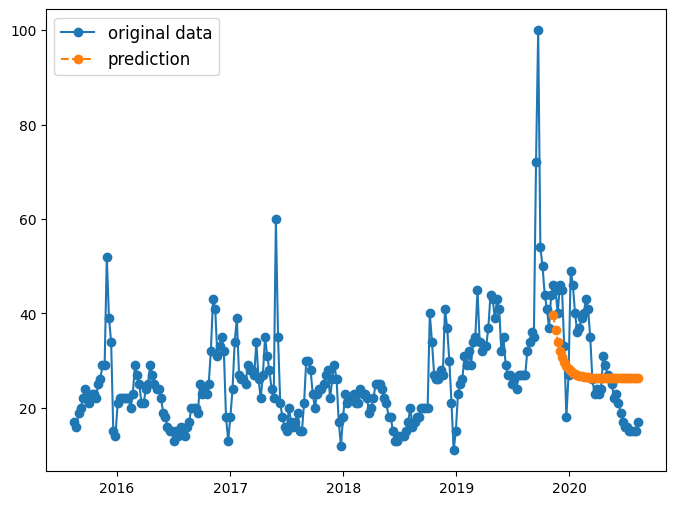

In [7]:
# Your code here...

# divide data into training and testing:
train = time_series[:-40]
test = time_series[-40:]

# choose the optimal lag using AIC (this is a model selection criterion)
mod = ar_select_order(train, maxlag=10, ic="bic")
optlag = max(mod.ar_lags)
print(optlag)

# fit our AR model using the tsa module! 
ar = tsa.AutoReg(train, lags=optlag)

# now we fit our model with the chosen optimal lag:
arfit = ar.fit()

# we make predictions on unseen data:
prediction = arfit.predict(end=time_series.index[-1])[-len(test):]

# produce some figures:
plt.figure(figsize=(8, 6))
plt.plot(time_series, '-o', label="original data")
plt.plot(prediction, '--o', label='prediction')

plt.legend(fontsize=12)

print('Out of sample MAE = {0:.3f}'.format(mean_absolute_error(test, prediction)))



Repeat for an ARMA process, using `arma_order_select_ic` to find the optimal parameters. How does the MAE compare to the AR process?

Note: in order to run an ARMA model using `statsmodels`, you can use `tsa.ARIMA` and set the `d` in the order as 0.

ARMA(p,q) = (np.int64(1), np.int64(0)) is the best.
Out of sample MAE = 8.170


/Users/SubasRW1/masters_project/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/SubasRW1/masters_project/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


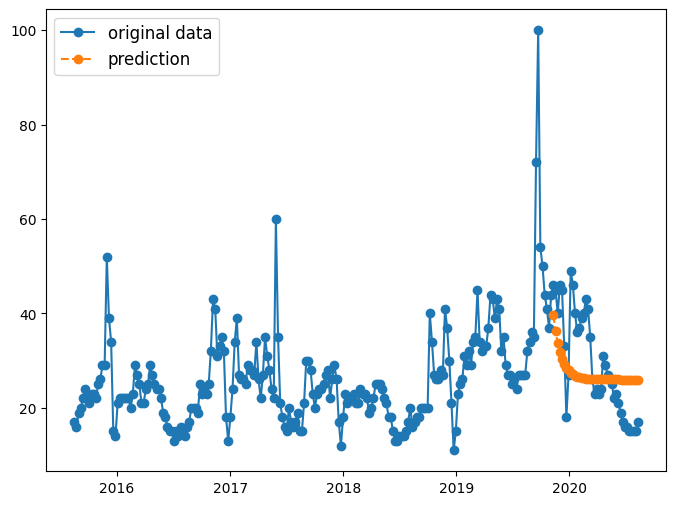

In [8]:
# Your code here...

# divide data into training and testing:
train = time_series[:-40]
test = time_series[-40:]

# fit our ARMA model using the tsa module! 
param_choice = tsa.arma_order_select_ic(train, max_ar=2, max_ma=2, ic='bic', trend='c')
print('ARMA(p,q) =',param_choice['bic_min_order'],'is the best.')

arma = tsa.ARIMA(
    train,
    order=(param_choice['bic_min_order'][0], 0, param_choice['bic_min_order'][1])
)
arma_fit = arma.fit()

# we make predictions on unseen data:
prediction = arma_fit.predict(end=time_series.index[-1])[-len(test):]

# produce some figures:
plt.figure(figsize=(8, 6))
plt.plot(time_series, '-o', label="original data")
plt.plot(prediction, '--o', label='prediction')

plt.legend(fontsize=12)

print('Out of sample MAE = {0:.3f}'.format(mean_absolute_error(test, prediction)))



## 5) Cross-Validation for Time Series Forecasting

Recall that it is important not to use future observations during a forecast. Below we will define a function to take a certain number of observations (ordered chronologically) as training data and use the remainder as testing data. We will also visualize their predictions :) 



In [9]:
def Forecasting_crossValidation( time_series, training_size, optlag ):
    """
    Given a pd.Series we train a autoregressive model. 
    The number of training observation is specified by the variable training_size
    """
    train = time_series[:training_size]
    test = time_series[training_size:]
    ar = tsa.AutoReg(train, lags=optlag)
    ar_result = ar.fit()
    prediction = ar_result.predict(end=time_series.index[-1])[-len(test):]
    # You could also use:
    #prediction = ar_result.predict(end=len(time_series)-1)[-len(test):]
    
    # compute the MAE:
    mae = mean_absolute_error(time_series.values[training_size:], prediction)
    print('Mean absolute error: ' + str(mae))
    
    # plot results as well:
    plt.plot(time_series.values, '-o', label='true')
    plt.plot(range(training_size, len(time_series)), prediction, 
         '-o', label='out of sample prediction')
    plt.legend();
    
    return prediction
    

Mean absolute error: 8.068257257751046


2019-11-10    40.898732
2019-11-17    36.486497
2019-11-24    34.326286
2019-12-01    32.962766
2019-12-08    31.664195
2019-12-15    30.562984
2019-12-22    29.717046
2019-12-29    29.053995
2020-01-05    28.520175
2020-01-12    28.092304
2020-01-19    27.751756
2020-01-26    27.480479
2020-02-02    27.263985
2020-02-09    27.091236
2020-02-16    26.953459
2020-02-23    26.843572
2020-03-01    26.755919
2020-03-08    26.686000
2020-03-15    26.630230
2020-03-22    26.585745
2020-03-29    26.550261
2020-04-05    26.521958
2020-04-12    26.499382
2020-04-19    26.481374
2020-04-26    26.467010
2020-05-03    26.455553
2020-05-10    26.446414
2020-05-17    26.439124
2020-05-24    26.433309
2020-05-31    26.428671
2020-06-07    26.424972
2020-06-14    26.422021
2020-06-21    26.419667
2020-06-28    26.417789
2020-07-05    26.416292
2020-07-12    26.415097
2020-07-19    26.414144
2020-07-26    26.413384
2020-08-02    26.412778
2020-08-09    26.412295
Freq: W-SUN, dtype: float64

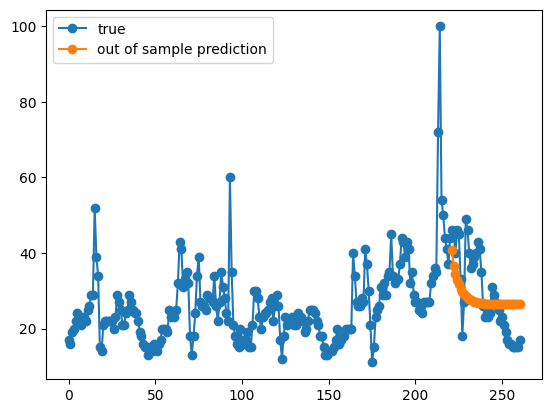

In [10]:
Forecasting_crossValidation( time_series, int(len(time_series)*0.85), 3)

#### Excercise:
Compute the average mean absolute error (MAE) for all possible forecasts (using a minimum of 30 training points). 

Hint: 

1) Copy the `Forecasting_crossValidation` function and adapt it so that it:
  - has an input parameter allowing you to specify the lags to use for the AR model
  - returns the MAE
  - Name this function `Forecasting_CV`
  Note: consider if you need it to output plots or not
  
2) Loop through the training sizes from length `30` to `len(time_series)-30`. In each loop do the following:
  - Select the optimal AR parameter according to the AIC using `ar_select_order` and just the training data
  - Use the function `Forecasting_CV` with your time series, current training size and selected lag to get a MAE
  - Append this MAE to a list which stores all of the errors from each training size

3) Print out the mean of your MAE list to get the average MAE for all possible forecasts


In [11]:
# Your code here...
def Forecasting_CV( time_series, training_size, optlag ):
    """
    Given a pd.Series we train a autoregressive model. 
    The number of training observation is specified by the variable training_size
    """
    train = time_series[:training_size]
    test = time_series[training_size:]
    ar = tsa.AutoReg(train, lags=optlag)
    ar_result = ar.fit()
    prediction = ar_result.predict(end=len(time_series)-1)[-len(test):]
    
    # compute the MAE:
    mae = mean_absolute_error(time_series.values[training_size:], prediction)
    
    return mae

mae_errors = []
for training_size in range(30, len(time_series)-30):
    # choose the optimal lag using AIC (this is a model selection criterion)
    mod = ar_select_order(time_series[:training_size], maxlag=10, ic="aic")
    optlag = max(mod.ar_lags)
    mae_errors.append(Forecasting_CV(time_series, training_size, optlag) )
    
    
print(np.mean(mae_errors))



9.318757714227116
